# U-Net Binary Segmentation for Schematic Wire Detection
Train a U-Net to separate handdrawn ink from background.
This is replicated apporach from https://arxiv.org/html/2402.11093v1.

This is to be run on google colab only.

This guide to Segmentation was heavily followed:https://medium.com/@heyamit10/pytorch-segmentation-models-a-practical-guide-5bf973a32e30

## 1. Mount Google Drive And Download Data


In [1]:
import kagglehub
from pathlib import Path
from google.colab import drive

drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
download_path = kagglehub.dataset_download("johannesbayer/cghd1152")
DATASET_ROOT = Path(download_path)

100%|██████████| 4.55G/4.55G [00:33<00:00, 146MB/s] 

Extracting files...


## 2. Install & Import Dependencies

In [ ]:
!pip install -q segmentation-models-pytorch albumentations patchify

import os, glob, random
import numpy as np
import cv2
from PIL import Image
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import segmentation_models_pytorch as smp
import albumentations as A
from albumentations.pytorch import ToTensorV2

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"Using device: {DEVICE}")


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.8/154.8 kB 5.2 MB/s eta 0:00:00
Using device: cuda


## 3. Dataset
Pairs each raw image with its corresponding segmentation mask image.

In [4]:

root_dir = Path(DATASET_ROOT)
seg_images = list(root_dir.glob(f'**/segmentation/*'))
image_pairs = []
missing_count = 0

for seg_path in seg_images:
    # assumes images are "../images/*" relative to the segmentation
    file_stem = seg_path.stem
    images_dir = seg_path.parent.parent / 'images'
    matches = list(images_dir.glob(f"{file_stem}.*"))    
    if matches:
        image_pairs.append((str(matches[0]), str(seg_path)))
           
    else:
        missing_count += 1

print(f"Total segmentation images found: {len(seg_images)}")
print(f"Successfully matched pairs:      {len(image_pairs)}")

if missing_count > 0:
    print(f"Warning: {missing_count} segmentation were missing their raw images file")

Total segmentation images found: 346
Successfully matched pairs:      346


### Defining the Transformations and DataLoader Class

Rather than resizing full images (which may distort and destroy important features), we sample random 256×256 patches at training time. 
Each image 200 random crops per epoch. Augmentations are light to reflect the true type of distortions expected in real life images of schematic diagrams. 

In [18]:
PATCH_SIZE = 256
PATCHES_PER_IMAGE = 200  

train_tf = A.Compose([
      A.RandomBrightnessContrast(p=0.35),
      A.GaussNoise(p=0.2),
      A.MotionBlur(blur_limit=3, p=0.15),
      A.Affine(
          translate_percent={"x": (-0.02, 0.02), "y": (-0.02, 0.02)},
          scale=(0.96, 1.04),
          rotate=(-5, 5),
          border_mode=cv2.BORDER_CONSTANT,
          fill=(255, 255, 255),
          fill_mask=0,
          p=0.3,
      ),
      A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
      ToTensorV2(),
  ])

# Validation transforms: normalization only — no stochastic augmentation.
val_tf = A.Compose([
    A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
    ToTensorV2(),
])


class SchematicSegDataset(Dataset):
    """
    Loads all image/mask pairs into memory at construction time, then serves
    random 256×256 crops at training time. The virtual dataset length is
    len(pairs) × patches_per_image, so each image is re-sampled many times
    per epoch with different random crops.
    """
    def __init__(self, pairs, transform, patches_per_image=PATCHES_PER_IMAGE, patch_size=PATCH_SIZE):
        self.pairs = pairs
        self.transform = transform
        self.patches_per_image = patches_per_image
        self.patch_size = patch_size

        self.cache = []
        for img_path, seg_path in pairs:
            img = cv2.imread(img_path)
            if img is None:
                raise FileNotFoundError(f'Could not read image: {img_path}')
            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
            mask = cv2.imread(seg_path, cv2.IMREAD_GRAYSCALE)
            if mask is None:
                raise FileNotFoundError(f'Could not read mask: {seg_path}')

            # Masks are binarised: dark pixels (ink/lines) → 1, light pixels (paper) → 0.
            mask = (mask < 127).astype(np.uint8) 
            self.cache.append((img,mask))
        print(f"Total Images Loaded: {len(self.cache)}")

    def __len__(self):
        return len(self.cache) * self.patches_per_image

    def __getitem__(self, idx):
        """
        Returns a randomly cropped and augmented patch from the dataset.
        """
        img, mask = self.cache[idx // self.patches_per_image]        
        h, w = img.shape[:2]
        p = self.patch_size

        # Sample a random patch, clamps to make sure patch does not go out of bounds
        y = random.randint(0, max(h - p, 0)) 
        x = random.randint(0, max(w - p, 0))
        img_patch  = img[y:y+p, x:x+p]
        mask_patch = mask[y:y+p, x:x+p]

        augmented = self.transform(image=img_patch, mask=mask_patch)

        # The mask needs to be convert to long because the diceloss function expects it that way, otherwise wont work
        return augmented['image'], augmented['mask'].long()




### Leakage-Safe Train / Validation / Test Split
Group images by drawing ID so all four photos of the same schematic stay in the same split.
Each drawing has up to four captured photos: `P1`, `P2`, `P3`, and `P4`.
These images share the same underlying circuit and drawing, so splitting them independently would leak nearly identical examples across train, validation, and test.

To avoid this, we group by `Cxxx_Dy` from filenames like:`C287_D1_P1.jpg -> C287_D1`.
Then we split the groups, not the individual images.

We are using a 80/10/10 test/val/train split

In [25]:

from collections import defaultdict
grouped_data = defaultdict(list)
for pair in image_pairs:
    suffix = "_".join(Path(pair[0]).stem.split("_")[:2])
    grouped_data[suffix].append(pair)

group_keys = list(grouped_data.keys())
random.seed(32)
random.shuffle(group_keys)

train_idx = int(0.80 * len(group_keys))
val_idx   = int(0.90 * len(group_keys))

train_keys = group_keys[:train_idx]
val_keys   = group_keys[train_idx:val_idx]
test_keys  = group_keys[val_idx:]
train_pairs = []
for k in train_keys:
    train_pairs.extend(grouped_data[k])

test_pairs = []
for k in test_keys:
    test_pairs.extend(grouped_data[k])
val_pairs = []
for k in val_keys:
    val_pairs.extend(grouped_data[k])

train_ds = SchematicSegDataset(train_pairs, train_tf)
val_ds   = SchematicSegDataset(val_pairs,   val_tf)
test_ds = SchematicSegDataset(test_pairs,   val_tf)

train_loader = DataLoader(train_ds, shuffle=True, batch_size=32,  num_workers=8, pin_memory=True)
val_loader   = DataLoader(val_ds,   batch_size=32,  num_workers=8, pin_memory=True)
test_loader = DataLoader(test_ds,   batch_size=32, num_workers=8, pin_memory=True)

print(f'Train pairs: {len(train_pairs)}, Val pairs: {len(val_pairs)}, Test pairs: {len(test_pairs)}')
print(f'Train batches: {len(train_loader)}, Val batches: {len(val_loader)}, Test batches: {len(test_loader)}')



Total Images Loaded: 277
Total Images Loaded: 35
Total Images Loaded: 34
Train pairs: 277, Val pairs: 35, Test pairs: 34
Train batches: 1732, Val batches: 219, Test batches: 213


## 4. Model
Using `segmentation_models_pytorch` which gives us a U-Net with a pretrained ResNet50 encoder.

In [27]:

EPOCHS = 30
model = smp.Unet(
    encoder_name='resnet50',
    encoder_weights='imagenet',
    in_channels=3,
    classes=1,
    activation=None,
).to(DEVICE)


loss_fn   = smp.losses.DiceLoss(mode='binary')
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-4, weight_decay=1e-4)
learning_rate_decayer = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)



## 5. Training Loop


In [28]:
scaler = torch.amp.GradScaler(device=DEVICE, enabled=(DEVICE == "cuda"))
def pixel_accuracy(preds, masks):
    preds_bin = (torch.sigmoid(preds.float()) > 0.5).squeeze(1)
    return (preds_bin == masks).float().mean().item()

def run_epoch(loader, train=True):
    model.train() if train else model.eval()
    total_loss, total_acc = 0, 0
    with torch.set_grad_enabled(train):
        for imgs, masks in loader:
            imgs  = imgs.to(DEVICE, non_blocking=True)
            masks = masks.to(DEVICE, non_blocking=True)
            with torch.amp.autocast(device_type=DEVICE):
                preds = model(imgs)
                loss  = loss_fn(preds, masks.unsqueeze(1).float()) # Loss function expects mask to be in a differnt format
            if train:
                optimizer.zero_grad()
                scaler.scale(loss).backward()
                scaler.step(optimizer)
                scaler.update()
            total_loss += loss.item()
            total_acc  += pixel_accuracy(preds, masks)
    return total_loss / len(loader), total_acc / len(loader)


early_stopping_threshold = 5
best_vl_loss = float("inf")
history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}
epochs_without_improvement = 0
for epoch in range(1, EPOCHS + 1):
    tr_loss, tr_acc = run_epoch(train_loader, train=True)
    vl_loss, vl_acc = run_epoch(val_loader,   train=False)
    learning_rate_decayer.step()

    history['train_loss'].append(tr_loss)
    history['val_loss'].append(vl_loss)
    history['train_acc'].append(tr_acc)
    history['val_acc'].append(vl_acc)

    print(f'Epoch {epoch:02d}/{EPOCHS} | train loss {tr_loss:.4f} acc {tr_acc:.4f} | val loss {vl_loss:.4f} acc {vl_acc:.4f}')

    if vl_loss < best_vl_loss:
        best_vl_loss = vl_loss
        torch.save(model.state_dict(), '/content/drive/MyDrive/unet_segmentation.pth')
        print(f' Saved best model (val loss {best_vl_loss:.4f})')
        epochs_without_improvement = 0
    else:

        epochs_without_improvement += 1
    
    if epochs_without_improvement >= early_stopping_threshold:
        print("Early stopping")
        break

    


Epoch 01/30 | train loss 0.3092 acc 0.9694 | val loss 0.1333 acc 0.9880
 Saved best model (val loss 0.1333)
Epoch 02/30 | train loss 0.1104 acc 0.9909 | val loss 0.1169 acc 0.9880
 Saved best model (val loss 0.1169)
Epoch 03/30 | train loss 0.0979 acc 0.9916 | val loss 0.1136 acc 0.9881
 Saved best model (val loss 0.1136)
Epoch 04/30 | train loss 0.0910 acc 0.9921 | val loss 0.1171 acc 0.9877
Epoch 05/30 | train loss 0.0875 acc 0.9924 | val loss 0.1230 acc 0.9875
Epoch 06/30 | train loss 0.0843 acc 0.9927 | val loss 0.1143 acc 0.9883
Epoch 07/30 | train loss 0.0803 acc 0.9930 | val loss 0.1100 acc 0.9887
 Saved best model (val loss 0.1100)
Epoch 08/30 | train loss 0.0791 acc 0.9931 | val loss 0.1113 acc 0.9889
Epoch 09/30 | train loss 0.0747 acc 0.9935 | val loss 0.1218 acc 0.9877
Epoch 10/30 | train loss 0.0727 acc 0.9936 | val loss 0.1170 acc 0.9875
Epoch 11/30 | train loss 0.0709 acc 0.9938 | val loss 0.1108 acc 0.9886
Epoch 12/30 | train loss 0.0683 acc 0.9940 | val loss 0.1101 acc

## 7. Plot Training History

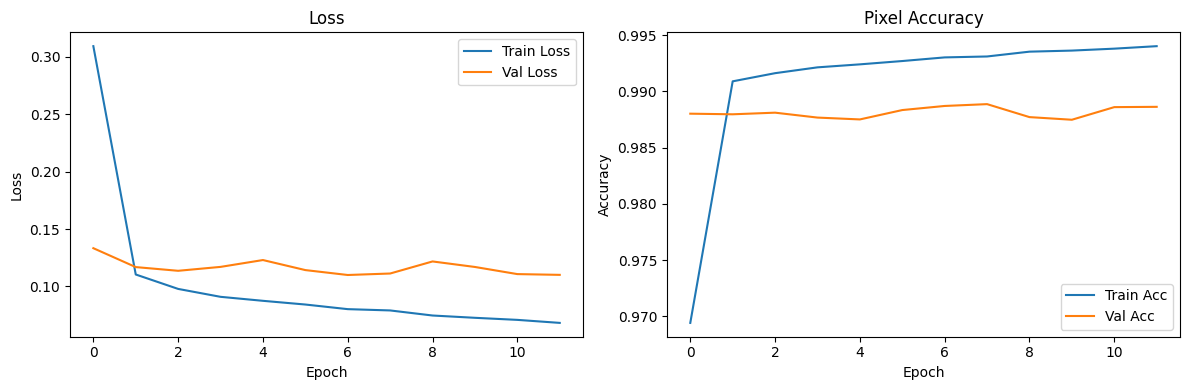

In [29]:
import matplotlib.pyplot as plt

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(history['train_loss'], label='Train Loss')
ax1.plot(history['val_loss'],   label='Val Loss')
ax1.set_title('Loss')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.legend()

ax2.plot(history['train_acc'], label='Train Acc')
ax2.plot(history['val_acc'],   label='Val Acc')
ax2.set_title('Pixel Accuracy')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Accuracy')
ax2.legend()

plt.tight_layout()
plt.savefig('history.png', dpi=150)
plt.show()

# 8. Test Assessment

In [30]:

model.load_state_dict(torch.load('/content/drive/MyDrive/unet_segmentation.pth', map_location=DEVICE))

def evaluate_test_set(loader, model):
    model.eval()
    total_loss,  total_acc = 0,  0

    with torch.no_grad():
        for imgs, masks in loader:
            imgs  = imgs.to(DEVICE, non_blocking=True)
            masks = masks.to(DEVICE, non_blocking=True)

            with torch.amp.autocast(device_type=DEVICE):
                preds = model(imgs)                              
                loss  = loss_fn(preds, masks.unsqueeze(1).float())  

            preds_bin = (torch.sigmoid(preds) > 0.5).squeeze(1)

            acc = (preds_bin == masks).float().mean()

            total_loss += loss.item()
            total_acc  += acc.item()

    n = len(loader)
    print(f"Test Loss    : {total_loss/n:.4f}  ")
    print(f"Acc    : {total_acc/n:.4f}")

evaluate_test_set(test_loader, model)

Test Loss    : 0.0902  
Acc    : 0.9914
